In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')


In [25]:
df=pd.read_csv("EV_Fleet_Synthetic_Dataset_v2.csv")

In [26]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df.describe()


Shape: (1057, 32)

Data Types:
 Record_ID                      int64
Timestamp                     object
Admin_ID                      object
Driver_ID                     object
Vehicle_ID                    object
Brand                         object
Vehicle_Model                 object
Category                      object
Max_Range_km                   int64
Battery_Capacity_kWh         float64
Vehicle_Weight_kg              int64
Motor_Spec_kW                  int64
Battery_Percentage           float64
Battery_Health_Percentage    float64
Passenger_Count                int64
Total_Load_Weight_kg         float64
Remaining_Range_km           float64
Road_Type                     object
Vehicle_Status                object
Speed_kmph                   float64
Overspeed                     object
Distance_Travelled_km        float64
Energy_Consumed_kWh          float64
Charging_Status               object
Charging_Duration_Hours      float64
Workshop_Visit                object
Mainte

,Record_ID,Max_Range_km,Battery_Capacity_kWh,Vehicle_Weight_kg,Motor_Spec_kW,Battery_Percentage,Battery_Health_Percentage,Passenger_Count,Total_Load_Weight_kg,Remaining_Range_km,Speed_kmph,Distance_Travelled_km,Energy_Consumed_kWh,Charging_Duration_Hours,Maintenance_Cost,OT_Maintenance_Cost,Income_Generated,Total_Expense,Driver_Safety_Score
count,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000,1057.000000
mean,529.000000,292.868496,48.750426,1659.838221,128.147588,58.852602,85.168307,2.581835,2281.209082,85.551561,52.540208,45.625355,12.444986,0.384011,329.353832,11.648061,1489.604541,1966.919584,97.656575
std,305.273921,103.593322,19.431931,297.614282,51.655647,22.683922,9.626553,1.739463,415.647444,77.970040,40.472968,14.883883,3.098972,0.891585,285.049311,97.446271,994.868921,543.717888,5.877565
min,1.000000,195.000000,20.000000,1165.000000,35.000000,8.000000,62.000000,0.000000,1283.000000,0.000000,0.000000,13.000000,4.180000,0.000000,0.000000,0.000000,0.000000,285.000000,63.000000
25%,265.000000,195.000000,34.600000,1421.000000,87.000000,43.300000,79.300000,1.000000,1993.000000,23.000000,19.000000,35.000000,10.400000,0.000000,137.000000,0.000000,894.000000,1621.000000,100.000000
50%,529.000000,265.000000,47.100000,1652.000000,124.000000,59.100000,86.100000,3.000000,2266.000000,69.000000,47.000000,44.000000,12.250000,0.000000,261.000000,0.000000,1523.000000,1934.000000,100.000000
75%,793.000000,341.000000,63.300000,1880.000000,161.000000,75.100000,92.400000,4.000000,2547.000000,125.000000,86.000000,54.000000,14.310000,0.000000,439.000000,0.000000,2095.000000,2298.000000,100.000000
max,1057.000000,600.000000,82.000000,2280.000000,254.000000,100.000000,100.000000,5.000000,3480.000000,451.000000,166.000000,102.000000,23.290000,3.600000,1882.000000,1166.000000,5844.000000,3868.000000,100.000000


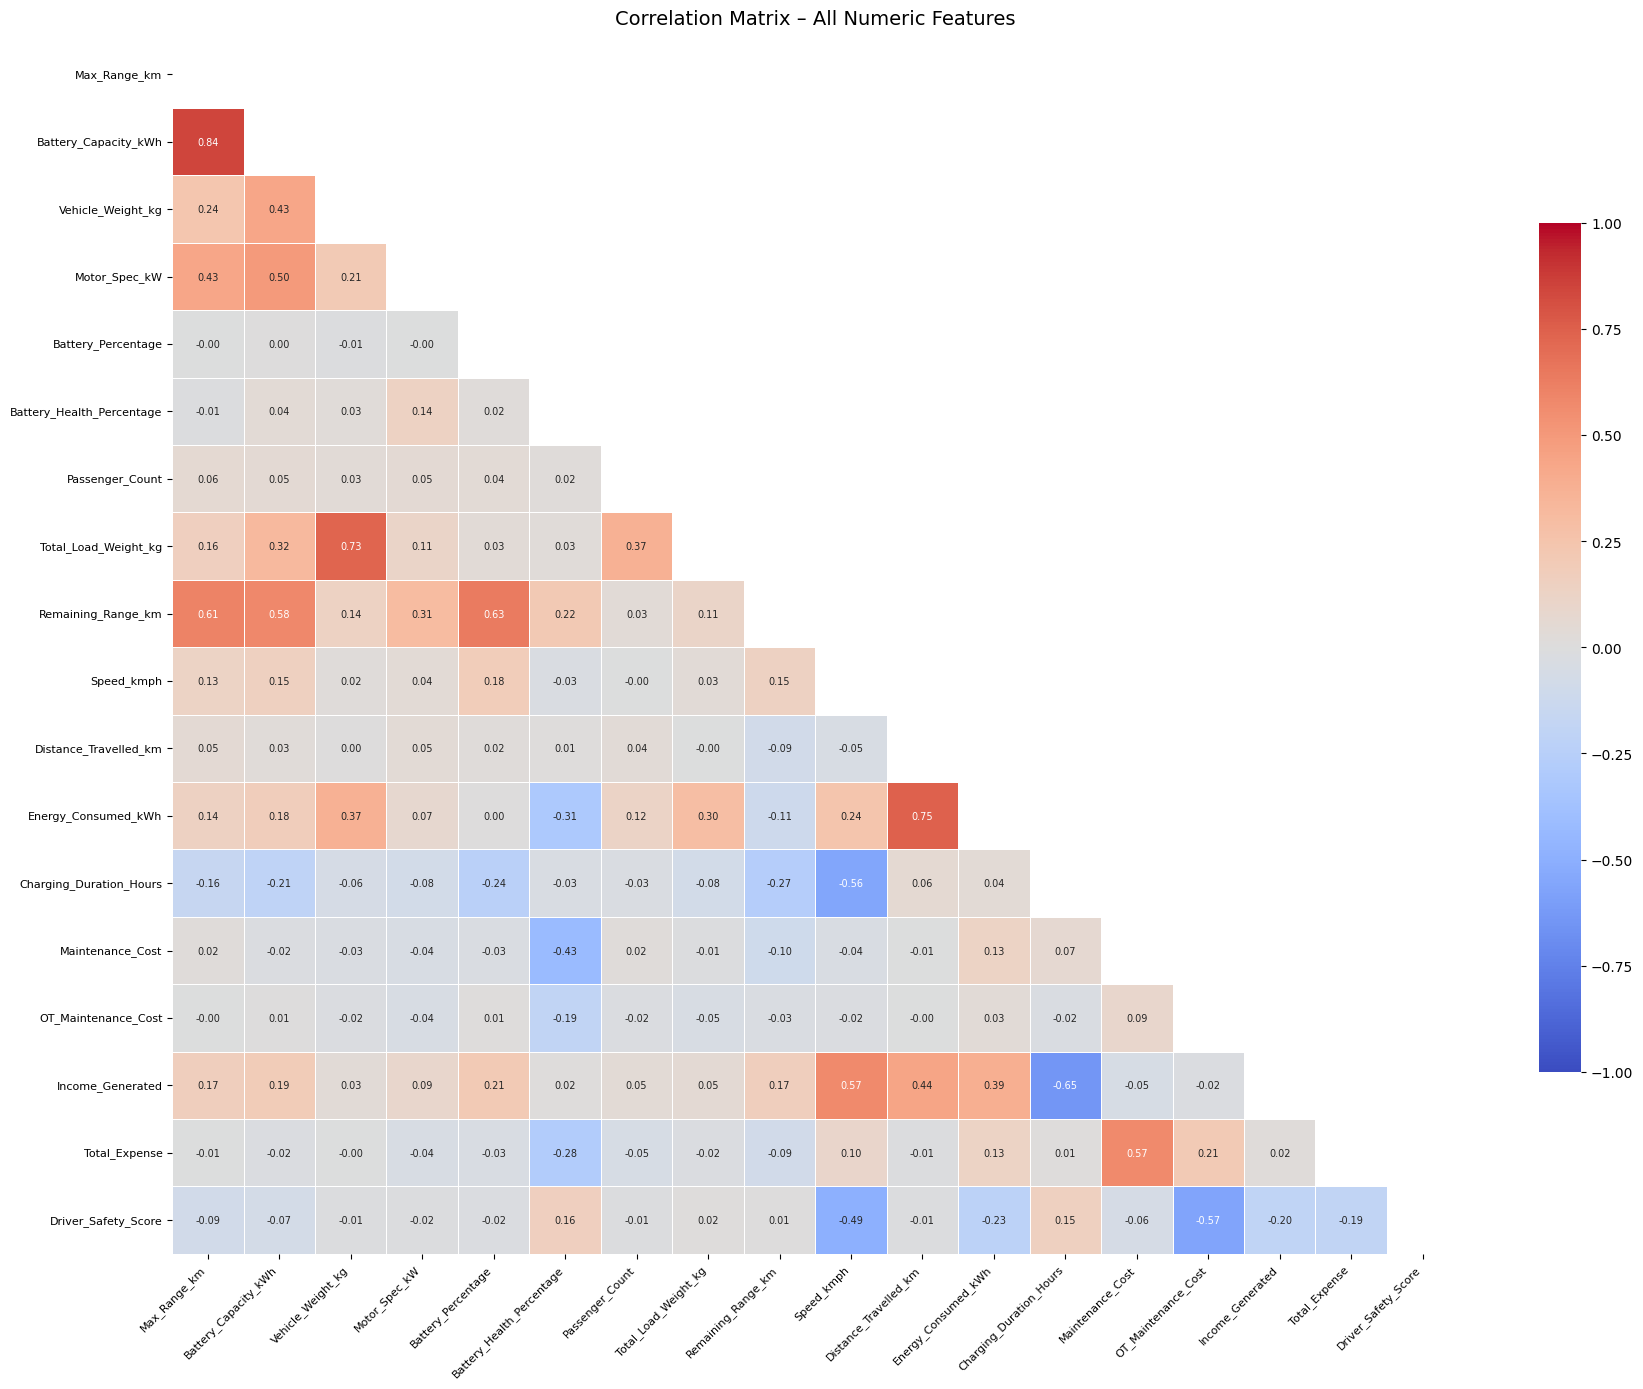

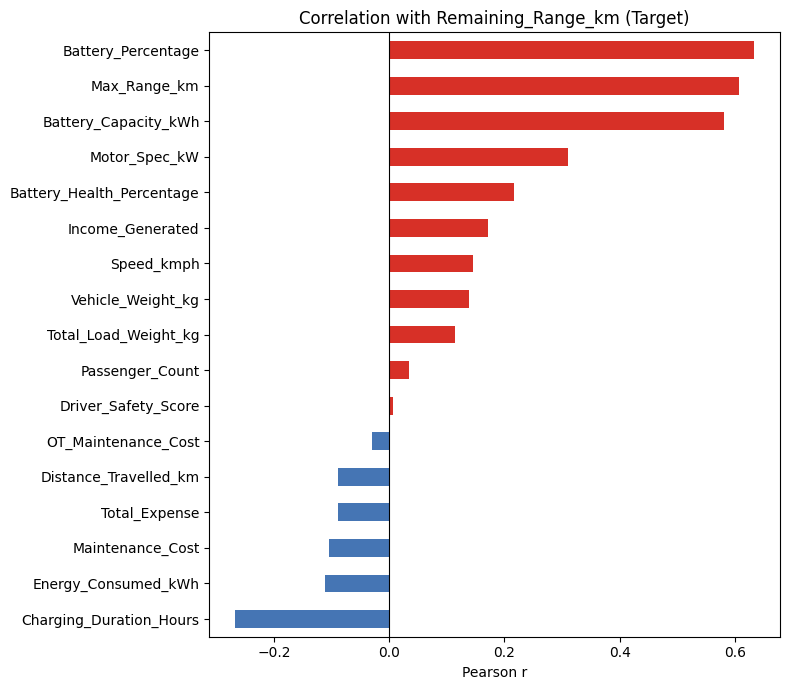

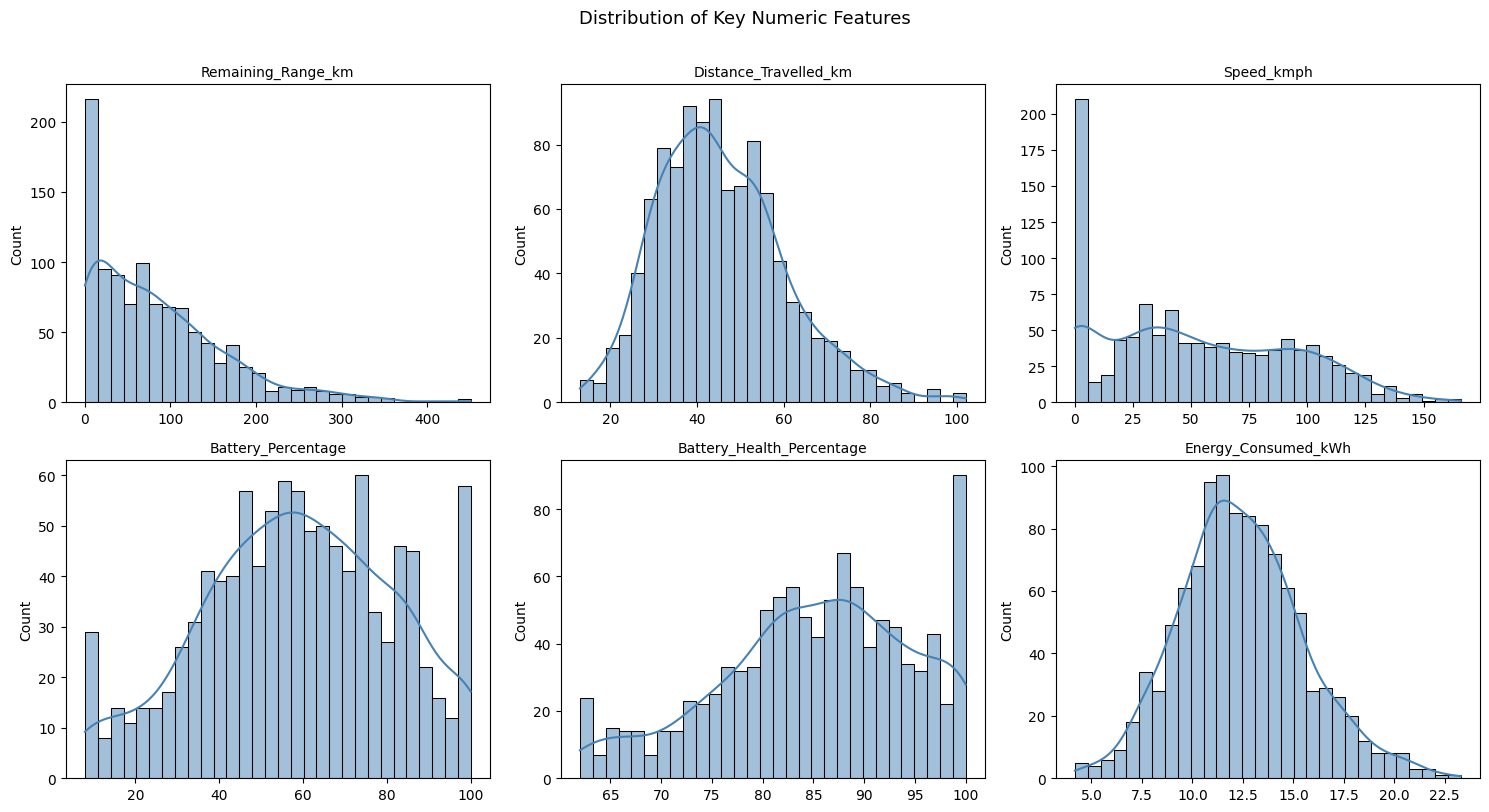

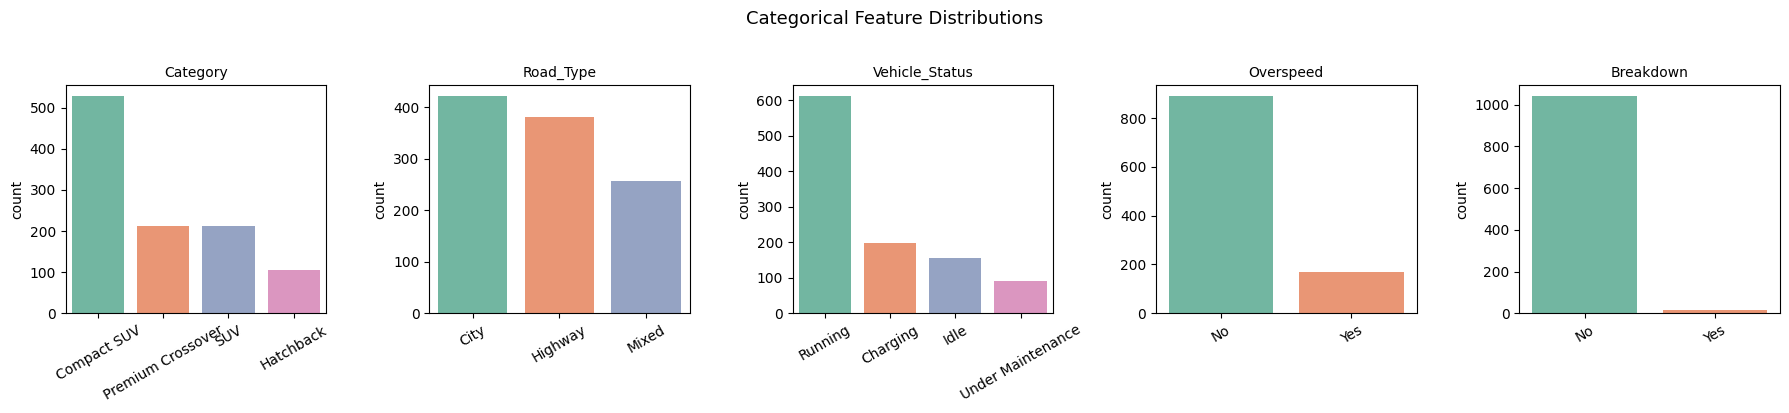

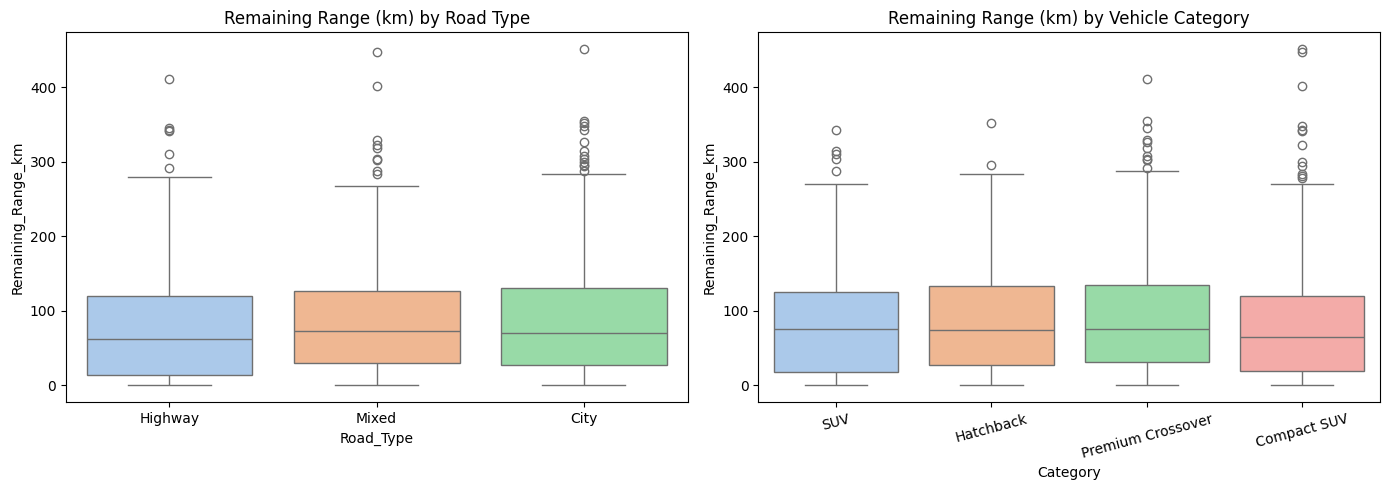

In [27]:
# ── Data Visualisation ─────────────────────────────────────────────────────────

numeric_df = df.select_dtypes(include='number').drop(columns=['Record_ID'])

# ── 1. Correlation Heatmap (all numeric features) ──────────────────────────────
plt.figure(figsize=(18, 14))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    linewidths=0.4, annot_kws={"size": 7}, vmin=-1, vmax=1,
    cbar_kws={"shrink": 0.7}
)
plt.title("Correlation Matrix – All Numeric Features", fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── 2. Top correlations with target (Remaining_Range_km) ──────────────────────
target_corr = corr['Remaining_Range_km'].drop('Remaining_Range_km').sort_values()
plt.figure(figsize=(8, 7))
colors = ['#d73027' if v > 0 else '#4575b4' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title("Correlation with Remaining_Range_km (Target)", fontsize=12)
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

# ── 3. Distribution of key numeric columns ─────────────────────────────────────
key_cols = ['Remaining_Range_km', 'Distance_Travelled_km', 'Speed_kmph',
            'Battery_Percentage', 'Battery_Health_Percentage', 'Energy_Consumed_kWh']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, key_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=30)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle("Distribution of Key Numeric Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 4. Categorical feature counts ─────────────────────────────────────────────
cat_plot_cols = ['Category', 'Road_Type', 'Vehicle_Status', 'Overspeed', 'Breakdown']
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle("Categorical Feature Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Remaining Range by Road Type & Category ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Road_Type', y='Remaining_Range_km', palette='pastel', ax=axes[0])
axes[0].set_title("Remaining Range (km) by Road Type")
sns.boxplot(data=df, x='Category', y='Remaining_Range_km', palette='pastel', ax=axes[1])
axes[1].set_title("Remaining Range (km) by Vehicle Category")
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


In [28]:
# ── Preprocessing ──────────────────────────────────────────────────────────────

# 1. Drop non-informative identifier / text columns
drop_cols = ['Record_ID', 'Timestamp', 'Admin_ID', 'Driver_ID', 'Vehicle_ID',
             'Brand', 'Vehicle_Model']
df_clean = df.drop(columns=drop_cols)

# 2. Encode binary Yes/No columns
binary_cols = ['Overspeed', 'Charging_Status', 'Workshop_Visit', 'Breakdown']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# 3. Label-encode remaining categorical columns
cat_cols = ['Category', 'Road_Type', 'Vehicle_Status']
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 4. Define target and features
TARGET = 'Remaining_Range_km'
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

# 5. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features shape:", X_scaled.shape)
print("Target shape  :", y.shape)
print("\nFeature columns:\n", list(X.columns))


Features shape: (1057, 24)
Target shape  : (1057,)

Feature columns:
 ['Category', 'Max_Range_km', 'Battery_Capacity_kWh', 'Vehicle_Weight_kg', 'Motor_Spec_kW', 'Battery_Percentage', 'Battery_Health_Percentage', 'Passenger_Count', 'Total_Load_Weight_kg', 'Road_Type', 'Vehicle_Status', 'Speed_kmph', 'Overspeed', 'Distance_Travelled_km', 'Energy_Consumed_kWh', 'Charging_Status', 'Charging_Duration_Hours', 'Workshop_Visit', 'Maintenance_Cost', 'OT_Maintenance_Cost', 'Breakdown', 'Income_Generated', 'Total_Expense', 'Driver_Safety_Score']


In [29]:
# ── Train / Test Split & Model Training ────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ── Evaluation ─────────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nModel: Random Forest Regressor  →  Target: {TARGET}")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")


Train: (845, 24)  |  Test: (212, 24)

Model: Random Forest Regressor  →  Target: Remaining_Range_km
  MAE  : 14.9721
  RMSE : 19.3695
  R²   : 0.9469


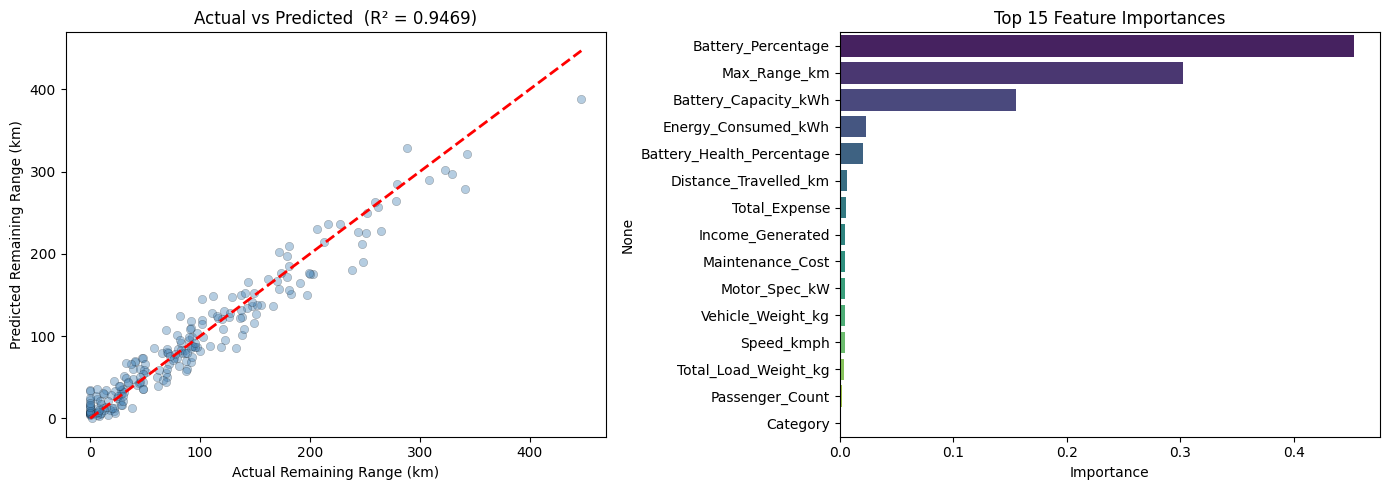

In [31]:
# ── Visualisations ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Remaining Range (km)")
axes[0].set_ylabel("Predicted Remaining Range (km)")
axes[0].set_title(f"Actual vs Predicted  (R² = {r2:.4f})")

# 2. Feature Importance (top 15)
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis', ax=axes[1])
axes[1].set_title("Top 15 Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()
